In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
sns.set_style('whitegrid')

In [6]:
df = pd.read_csv('diabetes_prediction_dataset.csv')

In [7]:
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


In [9]:
df.isnull().sum()

,0
gender,0
age,0
hypertension,0
heart_disease,0
smoking_history,0
bmi,0
HbA1c_level,0
blood_glucose_level,0
diabetes,0


In [11]:
df.shape

(100000, 9)

In [13]:
df.duplicated().sum()

np.int64(3854)

In [14]:
df['diabetes'].value_counts(normalize = True)

,proportion
diabetes,
0,0.915
1,0.085


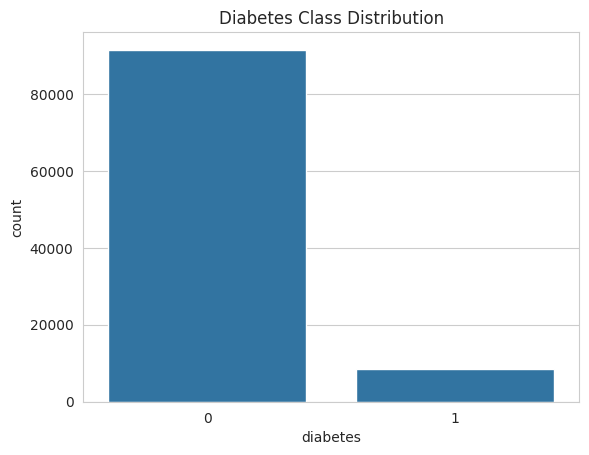

In [17]:
sns.countplot(x = 'diabetes', data = df)
plt.title("Diabetes Class Distribution")
plt.show()

In [20]:
df['smoking_history'].value_counts()

,count
smoking_history,
No Info,35816
never,35095
former,9352
current,9286
not current,6447
ever,4004


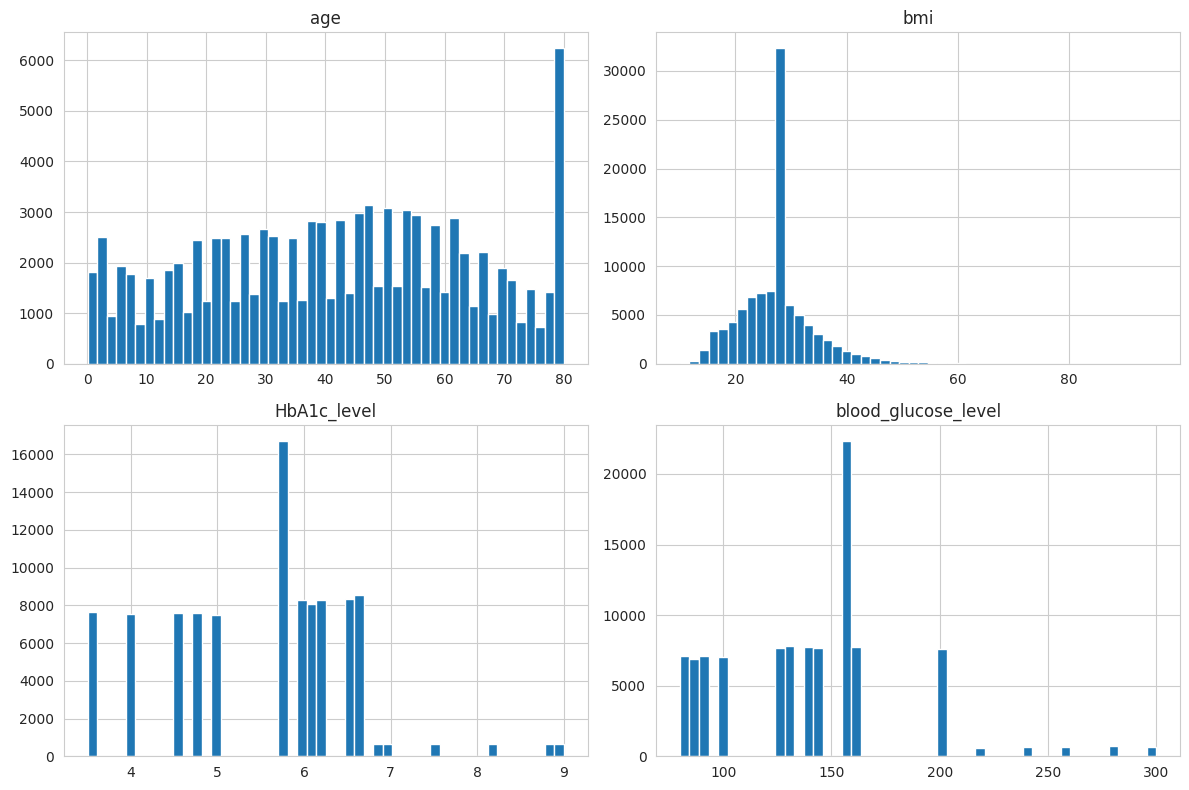

In [26]:
num_cols = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']
df[num_cols].hist(figsize=(12,8), bins=50)
plt.tight_layout()
plt.show()

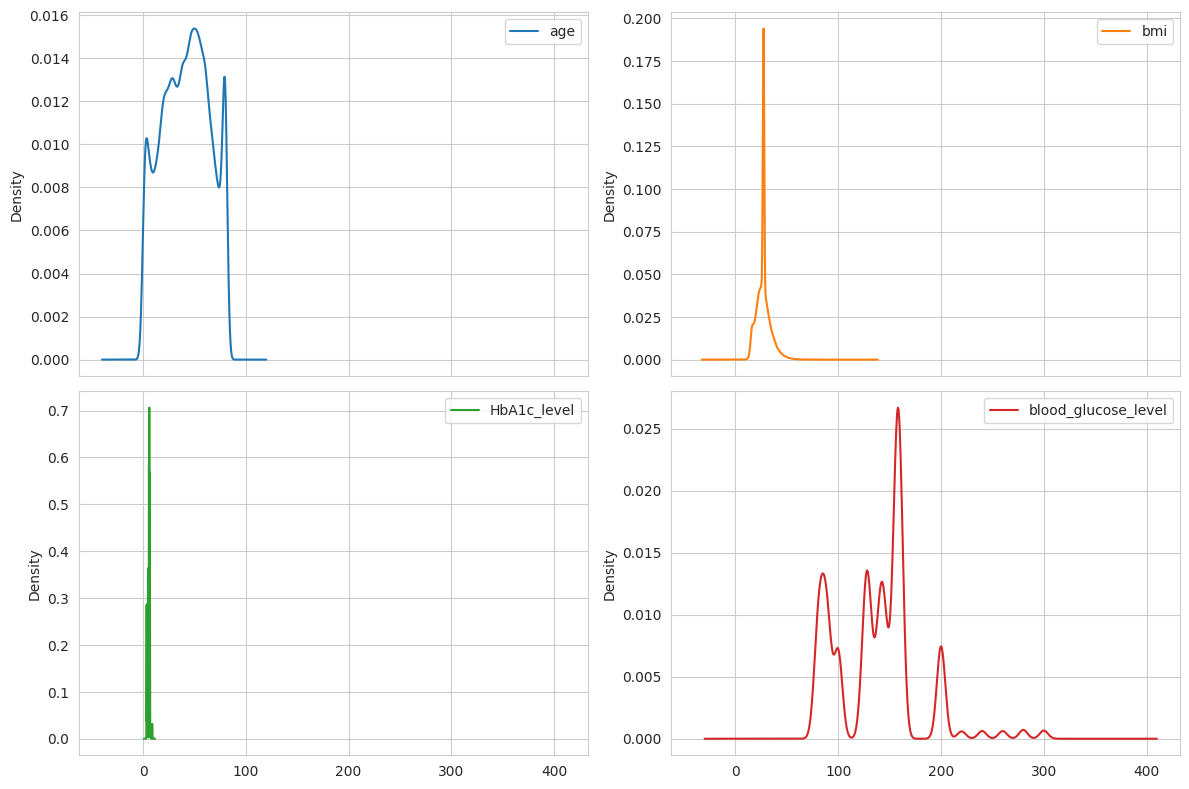

In [28]:
# Pandas ki madad se smooth density plot banana
df[num_cols].plot(kind='kde', subplots=True, layout=(2,2), figsize=(12,8))
plt.tight_layout()
plt.show()

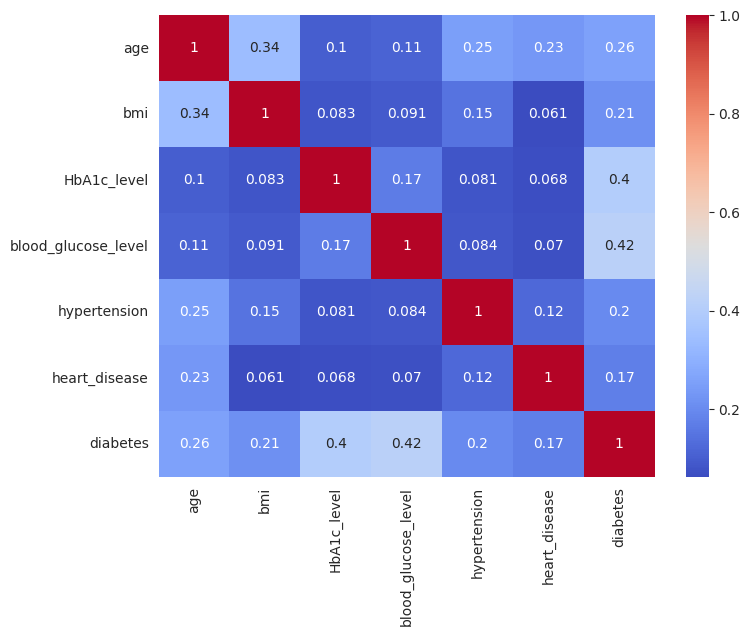

In [30]:
plt.figure(figsize=(8,6))
sns.heatmap(df[num_cols + ['hypertension','heart_disease','diabetes']].corr(), annot=True, cmap='coolwarm')
plt.show()

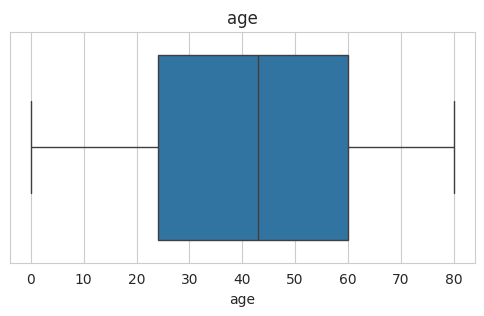

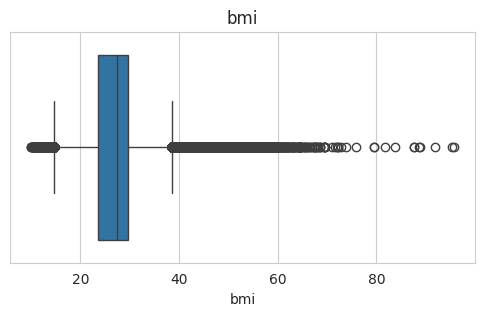

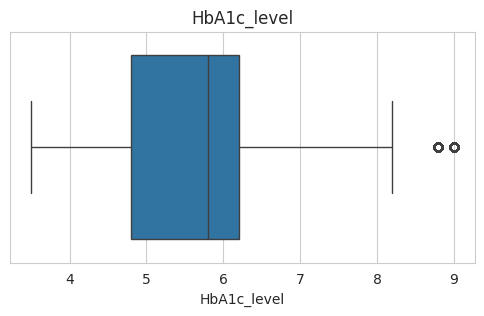

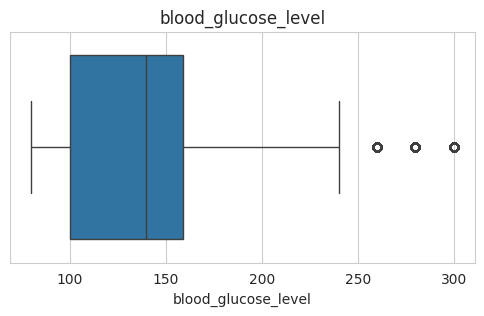

In [31]:
for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [32]:
df.to_csv("diabetes_cleaned.csv", index=False)

In [33]:
heart = pd.read_csv('heart.csv')

In [34]:
heart.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [35]:
heart.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [37]:
heart.duplicated().sum()

np.int64(723)

In [38]:
heart = heart.drop_duplicates()
heart.shape

(302, 14)

In [39]:
heart.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [40]:
heart['target'].value_counts(normalize = True)

,proportion
target,
1,0.543046
0,0.456954


In [41]:
heart.to_csv("heart_cleaned.csv", index=False)

In [43]:
kidney = pd.read_csv('kidney_disease_dataset.csv')

In [44]:
kidney.head()

,Age of the patient,Blood pressure (mm/Hg),Specific gravity of urine,Albumin in urine,Sugar in urine,Red blood cells in urine,Pus cells in urine,Pus cell clumps in urine,Bacteria in urine,Random blood glucose level (mg/dl),...,Smoking status,Body Mass Index (BMI),Physical activity level,Duration of diabetes mellitus (years),Duration of hypertension (years),Cystatin C level,Urinary sediment microscopy results,C-reactive protein (CRP) level,Interleukin-6 (IL-6) level,Target
0,54,167,1.023,1,4,normal,abnormal,not present,not present,96,...,yes,25.3,low,4,16,0.67,normal,4.88,10.23,No_Disease
1,42,127,1.023,3,2,normal,normal,not present,present,73,...,no,20.6,moderate,3,13,0.55,abnormal,4.49,13.11,Low_Risk
2,38,148,1.016,0,0,abnormal,normal,not present,not present,77,...,no,38.4,high,11,23,2.37,abnormal,4.57,13.27,No_Disease
3,7,98,1.017,4,0,abnormal,normal,not present,present,225,...,no,24.7,high,24,3,2.54,abnormal,8.57,12.36,No_Disease
4,67,174,1.015,1,1,normal,abnormal,not present,not present,376,...,yes,17.6,high,22,24,1.90,normal,6.75,1.46,No_Disease


In [45]:
kidney.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20538 entries, 0 to 20537
Data columns (total 43 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   Age of the patient                           20538 non-null  int64  
 1   Blood pressure (mm/Hg)                       20538 non-null  int64  
 2   Specific gravity of urine                    20538 non-null  float64
 3   Albumin in urine                             20538 non-null  int64  
 4   Sugar in urine                               20538 non-null  int64  
 5   Red blood cells in urine                     20538 non-null  object 
 6   Pus cells in urine                           20538 non-null  object 
 7   Pus cell clumps in urine                     20538 non-null  object 
 8   Bacteria in urine                            20538 non-null  object 
 9   Random blood glucose level (mg/dl)           20538 non-null  int64  
 10

In [46]:
kidney.shape

(20538, 43)

In [47]:
kidney.duplicated().sum()

np.int64(0)

In [48]:
kidney['Target_Binary'] = kidney['Target'].apply(lambda x: 0 if x == 'No_Disease' else 1)
kidney['Target_Binary'].value_counts(normalize=True)

,proportion
Target_Binary,
0,0.800078
1,0.199922


In [49]:
cat_cols = kidney.select_dtypes(include='object').columns.tolist()
print("Categorical columns:", cat_cols)

Categorical columns: ['Red blood cells in urine', 'Pus cells in urine', 'Pus cell clumps in urine', 'Bacteria in urine', 'Hypertension (yes/no)', 'Diabetes mellitus (yes/no)', 'Coronary artery disease (yes/no)', 'Appetite (good/poor)', 'Pedal edema (yes/no)', 'Anemia (yes/no)', 'Family history of chronic kidney disease', 'Smoking status', 'Physical activity level', 'Urinary sediment microscopy results', 'Target']


In [50]:
for col in cat_cols:
    print(col, ":", kidney[col].unique())

kidney.to_csv("kidney_cleaned.csv", index=False)

Red blood cells in urine : ['normal' 'abnormal']
Pus cells in urine : ['abnormal' 'normal']
Pus cell clumps in urine : ['not present' 'present']
Bacteria in urine : ['not present' 'present']
Hypertension (yes/no) : ['yes' 'no']
Diabetes mellitus (yes/no) : ['yes' 'no']
Coronary artery disease (yes/no) : ['no' 'yes']
Appetite (good/poor) : ['good' 'poor']
Pedal edema (yes/no) : ['no' 'yes']
Anemia (yes/no) : ['no' 'yes']
Family history of chronic kidney disease : ['no' 'yes']
Smoking status : ['yes' 'no']
Physical activity level : ['low' 'moderate' 'high']
Urinary sediment microscopy results : ['normal' 'abnormal']
Target : ['No_Disease' 'Low_Risk' 'Moderate_Risk' 'Severe_Disease' 'High_Risk']
